**Important Requried Libraries**

In [13]:
import tensorflow as tf
import numpy as np
import nltk
import os
import pickle
from tensorflow.keras import layers,metrics
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Activation, Dropout, Embedding, LSTM
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.optimizers import Adam


In [14]:
file = open("/content/ebook.txt","r",encoding = 'utf8')

#store file in list
lines = []
for i in file:
  lines.append(i)
# Convert list in to string
data = ""
for i in lines:
  data = ' '. join(lines)

#replace unnecessary stuff with space
data = data.replace('\n', '').replace('\r', '').replace('\ufeff', '').replace('“','').replace('”','')
#remove unnecessary spaces
data = data.split()
data = ' '.join(data)
data[:500]

'The Project Gutenberg eBook of Pride and Prejudice This ebook is for the use of anyone anywhere in the United States and most other parts of the world at no cost and with almost no restrictions whatsoever. You may copy it, give it away or re-use it under the terms of the Project Gutenberg License included with this ebook or online at www.gutenberg.org. If you are not located in the United States, you will have to check the laws of the country where you are located before using this eBook. Title:'

In [15]:
len(data)

63901

In [16]:
tok = Tokenizer()
tok.fit_on_texts([data])


In [17]:
pickle.dump(tok, open('token.pkl', 'wb'))

sequence_data = tok.texts_to_sequences([data])[0]
sequence_data[:15]

[1, 425, 347, 244, 2, 102, 3, 183, 46, 244, 11, 22, 1, 286, 2]

In [18]:
len(sequence_data)

11455

In [19]:
vocab_size = len(tok.word_index) + 1
print(vocab_size)

2401


In [20]:
sequence = []
for i in range(3,len(sequence_data)):
  words = sequence_data[i-3:i+1]
  sequence.append(words)
print("The Length of sequence are: ",len(sequence))
sequence = np.array(sequence)

The Length of sequence are:  11452


In [21]:
X = []
y = []
for i in sequence:
  X.append(i[0:3])
  y.append(i[3])
X = np.array(X)
y = np.array(y)

In [22]:
print('Data: ', X[:10])
print('Response: ', y[:10])

Data:  [[  1 425 347]
 [425 347 244]
 [347 244   2]
 [244   2 102]
 [  2 102   3]
 [102   3 183]
 [  3 183  46]
 [183  46 244]
 [ 46 244  11]
 [244  11  22]]
Response:  [244   2 102   3 183  46 244  11  22   1]


In [23]:
y = to_categorical(y, num_classes=vocab_size)

In [25]:
model = Sequential([
    layers.Embedding(vocab_size, 10, input_length=3),
    layers.LSTM(1000, return_sequences=True),
    layers.LSTM(1000),
    layers.Dense(1000, activation="relu"),
    layers.Dense(vocab_size, activation="softmax"),
])



/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


In [26]:
model.build(input_shape=(None, 3))


In [27]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 3, 10)          │        24,010 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 3, 1000)        │     4,044,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 1000)           │     8,004,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1000)           │     1,001,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 2401)           │     2,403,401 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 15,476,411 (59.04 MB)

 Trainable params: 15,476,411 (59.04 MB)

 Non-trainable params: 0 (0.00 B)

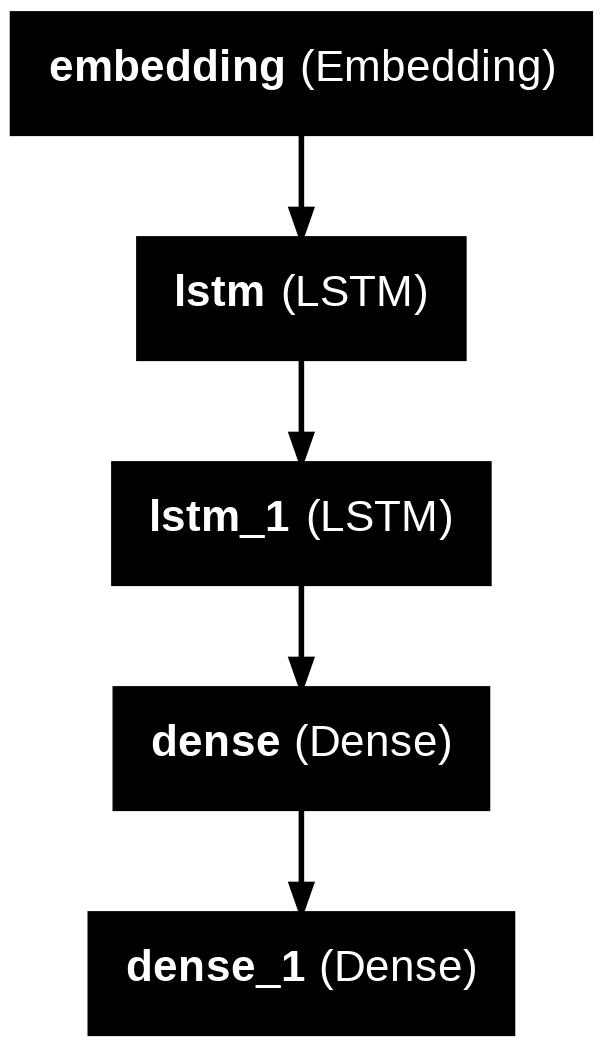

In [28]:
from tensorflow.keras.utils import plot_model
plot_model(model, to_file='plot.png', show_layer_names=True)

In [29]:
from tensorflow.keras.callbacks import ModelCheckpoint
checkpoint = ModelCheckpoint("next_words.h5", monitor='loss', verbose=1, save_best_only=True)
model.compile(loss="categorical_crossentropy", optimizer=Adam(learning_rate=0.001),metrics=['accuracy'])

In [31]:
model.fit(X,y,epochs=20,batch_size=64,validation_split=0.2,callbacks=[checkpoint])

Epoch 1/20
144/144 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.8697 - loss: 0.4925
Epoch 1: loss improved from 0.58651 to 0.51613, saving model to next_words.h5


144/144 ━━━━━━━━━━━━━━━━━━━━ 4s 27ms/step - accuracy: 0.8696 - loss: 0.4927 - val_accuracy: 0.0380 - val_loss: 25.3545
Epoch 2/20
142/144 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.8825 - loss: 0.4314
Epoch 2: loss improved from 0.51613 to 0.47851, saving model to next_words.h5


144/144 ━━━━━━━━━━━━━━━━━━━━ 5s 24ms/step - accuracy: 0.8821 - loss: 0.4323 - val_accuracy: 0.0340 - val_loss: 25.7354
Epoch 3/20
142/144 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.9051 - loss: 0.3707
Epoch 3: loss improved from 0.47851 to 0.40786, saving model to next_words.h5


144/144 ━━━━━━━━━━━━━━━━━━━━ 4s 24ms/step - accuracy: 0.9049 - loss: 0.3715 - val_accuracy: 0.0362 - val_loss: 26.0874
Epoch 4/20
142/144 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.9076 - loss: 0.3701
Epoch 4: loss improved from 0.40786 to 0.39306, saving model to next_words.h5


144/144 ━━━━━━━━━━━━━━━━━━━━ 4s 28ms/step - accuracy: 0.9075 - loss: 0.3706 - val_accuracy: 0.0393 - val_loss: 25.7942
Epoch 5/20
144/144 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.9194 - loss: 0.2923
Epoch 5: loss improved from 0.39306 to 0.32666, saving model to next_words.h5


...

144/144 ━━━━━━━━━━━━━━━━━━━━ 4s 25ms/step - accuracy: 0.9375 - loss: 0.2125 - val_accuracy: 0.0402 - val_loss: 26.8938
Epoch 14/20
142/144 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.9393 - loss: 0.2236
Epoch 14: loss did not improve from 0.23866
144/144 ━━━━━━━━━━━━━━━━━━━━ 3s 23ms/step - accuracy: 0.9392 - loss: 0.2242 - val_accuracy: 0.0367 - val_loss: 27.0248
Epoch 15/20
142/144 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.9423 - loss: 0.1930
Epoch 15: loss improved from 0.23866 to 0.21523, saving model to next_words.h5


144/144 ━━━━━━━━━━━━━━━━━━━━ 4s 24ms/step - accuracy: 0.9422 - loss: 0.1934 - val_accuracy: 0.0358 - val_loss: 26.5314
Epoch 16/20
142/144 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.9430 - loss: 0.1839
Epoch 16: loss improved from 0.21523 to 0.19008, saving model to next_words.h5


144/144 ━━━━━━━━━━━━━━━━━━━━ 4s 24ms/step - accuracy: 0.9430 - loss: 0.1840 - val_accuracy: 0.0362 - val_loss: 26.5100
Epoch 17/20
142/144 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.9553 - loss: 0.1520
Epoch 17: loss improved from 0.19008 to 0.17402, saving model to next_words.h5


144/144 ━━━━━━━━━━━━━━━━━━━━ 4s 28ms/step - accuracy: 0.9552 - loss: 0.1525 - val_accuracy: 0.0371 - val_loss: 26.6988
Epoch 18/20
142/144 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.9530 - loss: 0.1542
Epoch 18: loss improved from 0.17402 to 0.16213, saving model to next_words.h5


144/144 ━━━━━━━━━━━━━━━━━━━━ 4s 25ms/step - accuracy: 0.9529 - loss: 0.1543 - val_accuracy: 0.0340 - val_loss: 26.1656
Epoch 19/20
142/144 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.9535 - loss: 0.1501
Epoch 19: loss did not improve from 0.16213
144/144 ━━━━━━━━━━━━━━━━━━━━ 3s 22ms/step - accuracy: 0.9534 - loss: 0.1504 - val_accuracy: 0.0340 - val_loss: 26.5857
Epoch 20/20
142/144 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.9519 - loss: 0.1449
Epoch 20: loss did not improve from 0.16213
144/144 ━━━━━━━━━━━━━━━━━━━━ 3s 22ms/step - accuracy: 0.9518 - loss: 0.1454 - val_accuracy: 0.0358 - val_loss: 26.8810


In [34]:
from tensorflow.keras.models import load_model

In [35]:
# loading the model for prediction
model = load_model("/content/next_words.h5")

In [36]:
tokenizer = pickle.load(open('/content/token.pkl', 'rb'))


In [38]:
def Prediction_Next_Word(model, tokenizer, text):
  sequence = tokenizer.texts_to_sequences([text])
  sequence = np.array(sequence)
  preds = np.argmax(model.predict(sequence))
  predicted_word = ""

  for key, value in tokenizer.word_index.items():
      if value == preds:
          predicted_word = key
          break

  print(predicted_word)
  return predicted_word

In [39]:
while(True):
  text = input("Enter your text Line: ")
  if text == "0":
    print("Executing complete.....")
    break
  else:
    try:
      text = text.split(" ")
      text = text[-3:]
      print(text)
      print(Prediction_Next_Word(model, tokenizer, text))

    except Exception as e:
      print("Error Occured: ",e)
      continue

Enter your text Line: The Project
['The', 'Project']
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 221ms/step
language
language
Enter your text Line: the love
['the', 'love']
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
of
of
Enter your text Line: Gutenberg eBook
['Gutenberg', 'eBook']
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
with
with
Enter your text Line: This ebook
['This', 'ebook']
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
of
of
Enter your text Line: is for the use of anyone
['use', 'of', 'anyone']
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 200ms/step
anywhere
anywhere
Enter your text Line: Pride and
['Pride', 'and']
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
prejudice
prejudice
Enter your text Line:  Chuck Greif 
['Chuck', 'Greif', '']
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
that
that
Enter your text Line: Online Distributed Proofreading Team at
['Proofreading', 'Team', 'at']
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
http
http
Enter your text Line: q
['q']
Error Occured:  Exception encountered when calling LSTM.call().

slice index 0 of 